# Лабораторная работа №1  
## Анализ и прогнозирование временных рядов на примере розничных продаж

**Цель работы:** провести разведочный анализ временного ряда розничных продаж, выполнить декомпозицию несколькими методами, построить и сравнить прогнозные модели ARIMA и SARIMAX.

**Исходные данные:** `retail_sales_mock_data.csv`.

В работе выполнены:

1. подготовка и проверка данных;
2. разведочный анализ временного ряда;
3. декомпозиция ряда классическими методами, FFT и вейвлет-анализом;
4. построение прогнозных моделей ARIMA и SARIMAX;
5. оценка качества, анализ остатков и итоговая интерпретация.

In [1]:
# Базовые библиотеки для работы с данными
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Статистические и ML-инструменты
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.gofplots import qqplot

from IPython.display import display

# Настройки отображения таблиц и графиков
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 1. Загрузка и предварительная подготовка данных

На первом этапе загружаем CSV-файл, приводим дату к типу `datetime`, сортируем наблюдения по времени и задаём месячную частоту ряда.  
Целевая переменная для прогнозирования — `SalesAmount`.

In [2]:
# Путь рассчитан так, чтобы ноутбук работал и локально рядом с CSV, и в среде проверки ChatGPT.
DATA_PATH = Path("retail_sales_mock_data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/retail_sales_mock_data.csv")

# Загружаем данные
raw_df = pd.read_csv(DATA_PATH)

# Приводим колонку Date к datetime и сортируем временной ряд
raw_df["Date"] = pd.to_datetime(raw_df["Date"])
df = raw_df.sort_values("Date").set_index("Date")

# Так как данные месячные, явно задаём частоту Month Start (MS)
df = df.asfreq("MS")

# Выделяем целевой ряд и экзогенные признаки
TARGET = "SalesAmount"
EXOG_COLS = ["Promotion", "HolidayMonth"]
y = df[TARGET].astype(float)
exog = df[EXOG_COLS].astype(float)

print(f"Размер данных: {df.shape[0]} наблюдений, {df.shape[1]} признака")
print(f"Период наблюдений: {df.index.min().date()} — {df.index.max().date()}")
print(f"Частота ряда: {df.index.freqstr}")

display(df.head())
display(df.tail())

Размер данных: 48 наблюдений, 3 признака
Период наблюдений: 2020-01-01 — 2023-12-01
Частота ряда: MS


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


,SalesAmount,Promotion,HolidayMonth
Date,,,
2023-08-01,11566,0,0
2023-09-01,11759,0,0
2023-10-01,11890,0,0
2023-11-01,11770,0,0
2023-12-01,17996,0,1


In [3]:
# Проверяем типы данных, пропуски и дубликаты дат
quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_share": df.isna().mean(),
    "unique_values": df.nunique()
})

print("Количество дубликатов по индексу Date:", df.index.duplicated().sum())
display(quality_report)

display(df.describe().T)

Количество дубликатов по индексу Date: 0


,dtype,missing_count,missing_share,unique_values
SalesAmount,int64,0,0.0000,48
Promotion,int64,0,0.0000,2
HolidayMonth,int64,0,0.0000,2


,count,mean,std,min,25%,50%,75%,max
SalesAmount,48.0000,"11,768.5417","2,257.5449","7,783.0000","10,219.7500","11,851.0000","13,014.0000","17,996.0000"
Promotion,48.0000,0.1250,0.3342,0.0000,0.0000,0.0000,0.0000,1.0000
HolidayMonth,48.0000,0.0833,0.2793,0.0000,0.0000,0.0000,0.0000,1.0000


### Аналитический вывод по пункту 1

Данные представляют собой регулярный месячный временной ряд за 4 года: с января 2020 года по декабрь 2023 года. Пропусков и дубликатов дат нет, поэтому ряд можно напрямую использовать для EDA, декомпозиции и построения моделей.  
В наборе данных есть две потенциально полезные объясняющие переменные: `Promotion` отражает наличие промо-активности, а `HolidayMonth` — праздничный месяц. Эти признаки логично использовать в SARIMAX как экзогенные регрессоры.

## 2. Разведочный анализ данных (EDA)

На этом этапе визуально и статистически изучаем динамику продаж: общий вид ряда, распределение значений, поведение по годам и месяцам, а также связь продаж с промо-активностями и праздничными месяцами.

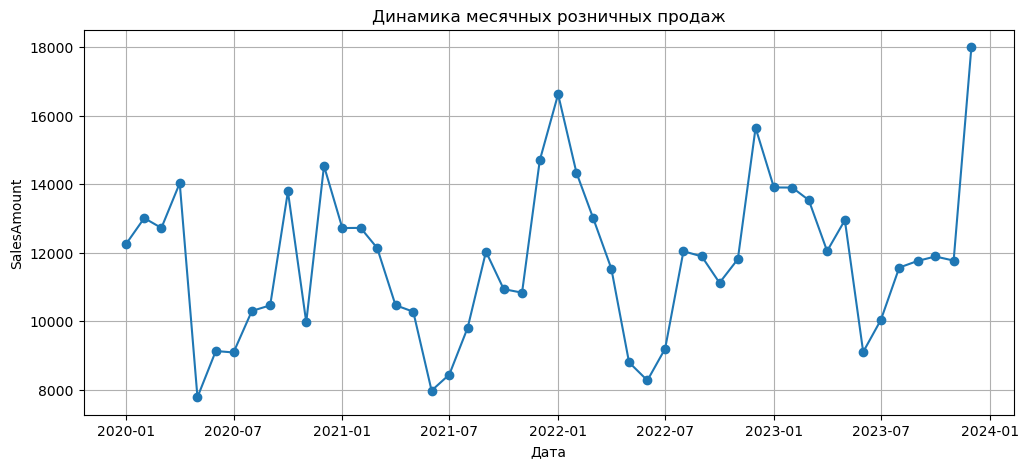

In [4]:
# График исходного временного ряда
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y.index, y.values, marker="o")
ax.set_title("Динамика месячных розничных продаж")
ax.set_xlabel("Дата")
ax.set_ylabel("SalesAmount")
plt.show()

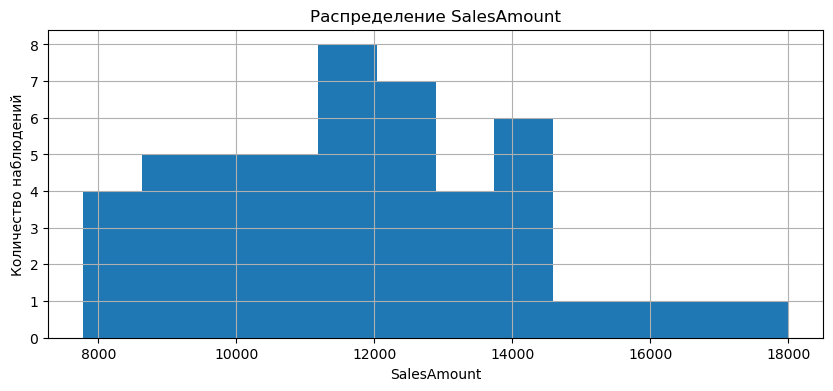

,sum,mean,median,min,max,std
year,,,,,,
2020,137067,"11,422.2500","11,356.0000",7783,14534,"2,240.0010"
2021,133056,"11,088.0000","10,885.5000",7976,14696,"1,901.5451"
2022,144304,"12,025.3333","11,852.0000",8273,16623,"2,596.6040"
2023,150463,"12,538.5833","11,969.0000",9104,17996,"2,246.1735"


In [5]:
# Добавляем календарные признаки для EDA
eda_df = df.copy()
eda_df["year"] = eda_df.index.year
eda_df["month"] = eda_df.index.month
eda_df["month_name"] = eda_df.index.month_name()

# Распределение целевой переменной
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(eda_df[TARGET], bins=12)
ax.set_title("Распределение SalesAmount")
ax.set_xlabel("SalesAmount")
ax.set_ylabel("Количество наблюдений")
plt.show()

# Сводка по годам
annual_stats = eda_df.groupby("year")[TARGET].agg(["sum", "mean", "median", "min", "max", "std"])
display(annual_stats)

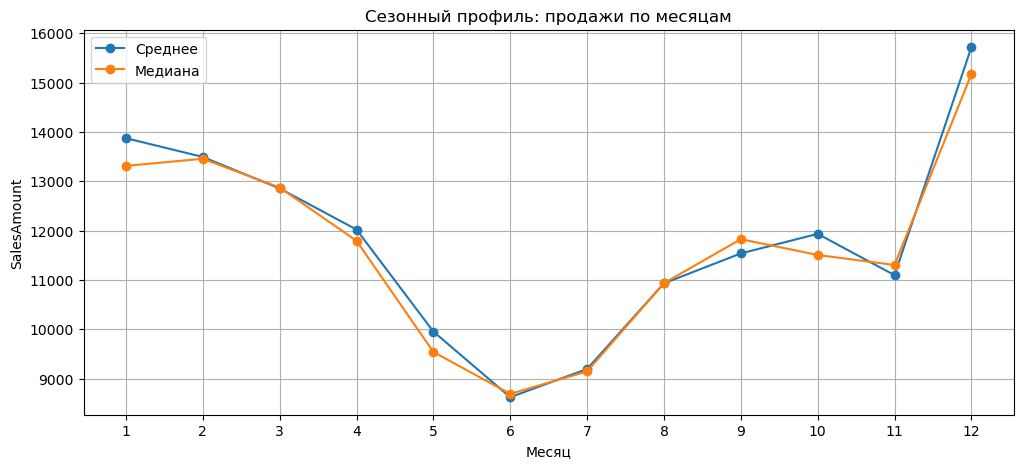

,mean,median,min,max
month,,,,
1,"13,873.7500","13,312.0000",12248,16623
2,"13,493.0000","13,456.0000",12724,14336
3,"12,853.7500","12,872.5000",12136,13534
4,"12,020.7500","11,792.5000",10468,14030
5,"9,952.7500","9,539.5000",7783,12949
6,"8,621.0000","8,688.5000",7976,9131
7,"9,193.7500","9,144.0000",8445,10042
8,"10,929.7500","10,933.0000",9810,12043
9,"11,536.5000","11,825.5000",10464,12031


In [6]:
# Средние продажи по месяцам позволяют увидеть сезонный профиль
monthly_profile = eda_df.groupby("month")[TARGET].agg(["mean", "median", "min", "max"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_profile.index, monthly_profile["mean"], marker="o", label="Среднее")
ax.plot(monthly_profile.index, monthly_profile["median"], marker="o", label="Медиана")
ax.set_title("Сезонный профиль: продажи по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("SalesAmount")
ax.set_xticks(range(1, 13))
ax.legend()
plt.show()

display(monthly_profile)

Продажи в зависимости от Promotion:


,count,mean,median,min,max
Promotion,,,,,
0,42,"11,621.2381","11,791.0000",7783,17996
1,6,"12,799.6667","13,367.5000",9131,16623


Продажи в зависимости от HolidayMonth:


,count,mean,median,min,max
HolidayMonth,,,,,
0,44,"11,409.5227","11,764.5000",7783,16623
1,4,"15,717.7500","15,170.5000",14534,17996


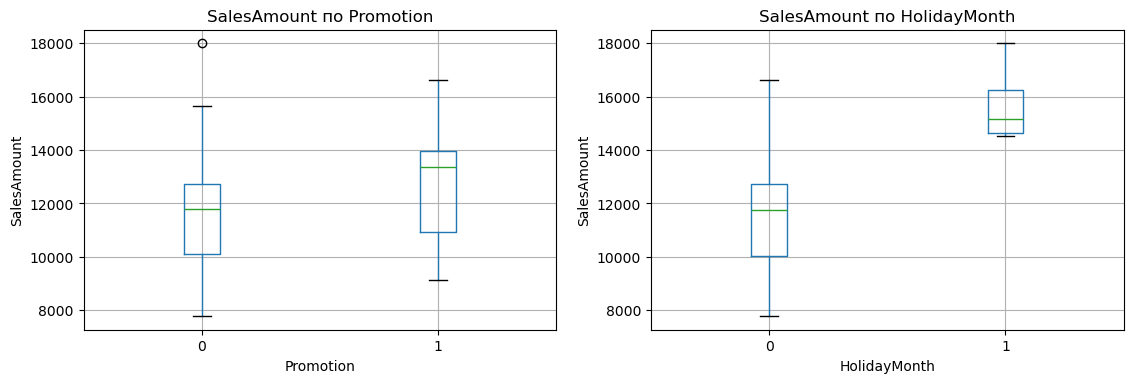

In [7]:
# Сравниваем продажи в обычные, промо- и праздничные месяцы
promo_stats = eda_df.groupby("Promotion")[TARGET].agg(["count", "mean", "median", "min", "max"])
holiday_stats = eda_df.groupby("HolidayMonth")[TARGET].agg(["count", "mean", "median", "min", "max"])

print("Продажи в зависимости от Promotion:")
display(promo_stats)

print("Продажи в зависимости от HolidayMonth:")
display(holiday_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
eda_df.boxplot(column=TARGET, by="Promotion", ax=axes[0])
axes[0].set_title("SalesAmount по Promotion")
axes[0].set_xlabel("Promotion")
axes[0].set_ylabel("SalesAmount")

eda_df.boxplot(column=TARGET, by="HolidayMonth", ax=axes[1])
axes[1].set_title("SalesAmount по HolidayMonth")
axes[1].set_xlabel("HolidayMonth")
axes[1].set_ylabel("SalesAmount")

plt.suptitle("")
plt.show()

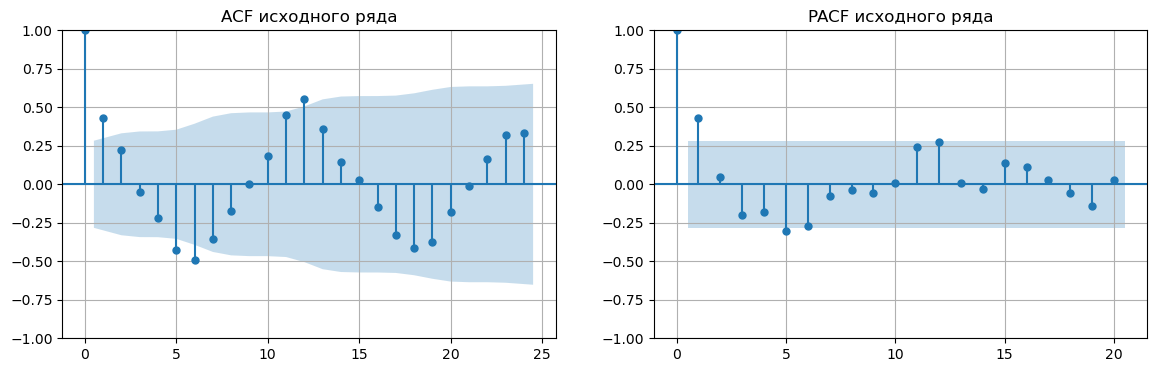

ADF statistic: -4.5142
p-value: 0.0002


In [8]:
# Автокорреляция помогает предварительно оценить наличие сезонности и подобрать параметры ARIMA/SARIMAX
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y, lags=24, ax=axes[0])
axes[0].set_title("ACF исходного ряда")
plot_pacf(y, lags=20, method="ywm", ax=axes[1])
axes[1].set_title("PACF исходного ряда")
plt.show()

# Тест Дики-Фуллера: проверяем стационарность исходного ряда
adf_stat, adf_pvalue, *_ = adfuller(y)
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value: {adf_pvalue:.4f}")

### Аналитический вывод по пункту 2

Ряд имеет выраженную годовую сезонность: в отдельные месяцы продажи систематически выше, особенно в праздничные периоды. Это подтверждается сезонным профилем по месяцам и заметными всплесками на графике временного ряда.  
Признак `HolidayMonth` визуально связан с более высокими продажами, поэтому его важно учитывать в модели. Признак `Promotion` также может объяснять часть колебаний, хотя эффект промо-месяцев может быть менее устойчивым из-за небольшого числа наблюдений.  
ACF/PACF показывают автокорреляционную структуру и сезонные лаги, поэтому для прогноза разумно сравнивать простую ARIMA и сезонную SARIMAX с периодом 12 месяцев.

## 3. Декомпозиция временного ряда

В задании требуется использовать три группы методов:

1. классическая декомпозиция: аддитивная, мультипликативная и STL;
2. спектральный анализ через быстрое преобразование Фурье (FFT);
3. вейвлет-анализ.

Декомпозиция помогает отделить тренд, сезонность и шум, а также понять, какие компоненты важны для прогнозной модели.

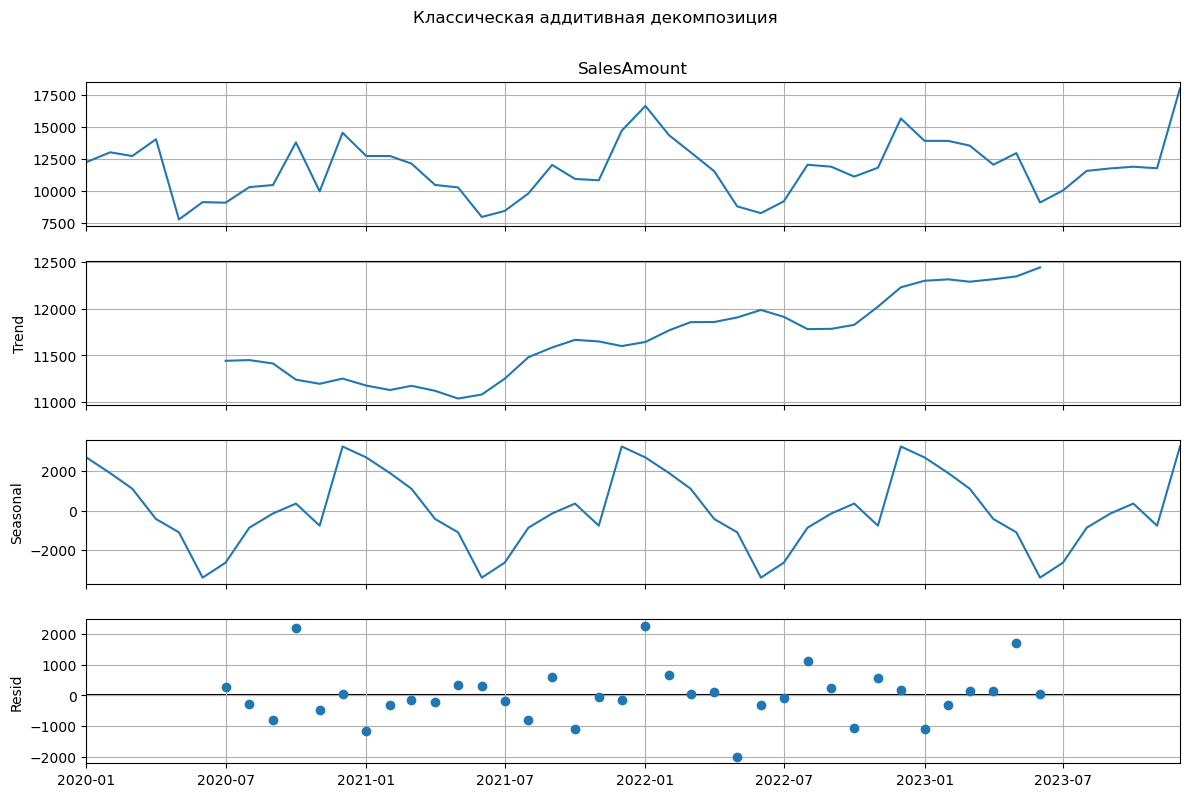

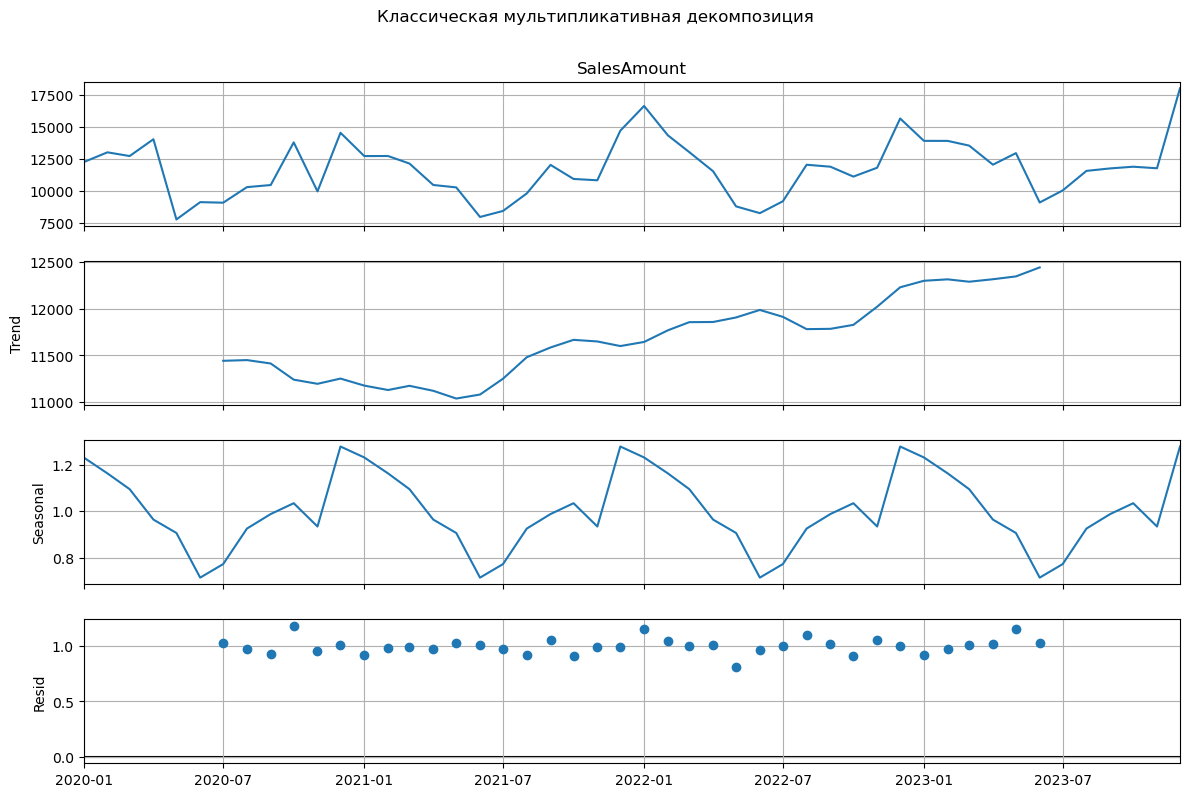

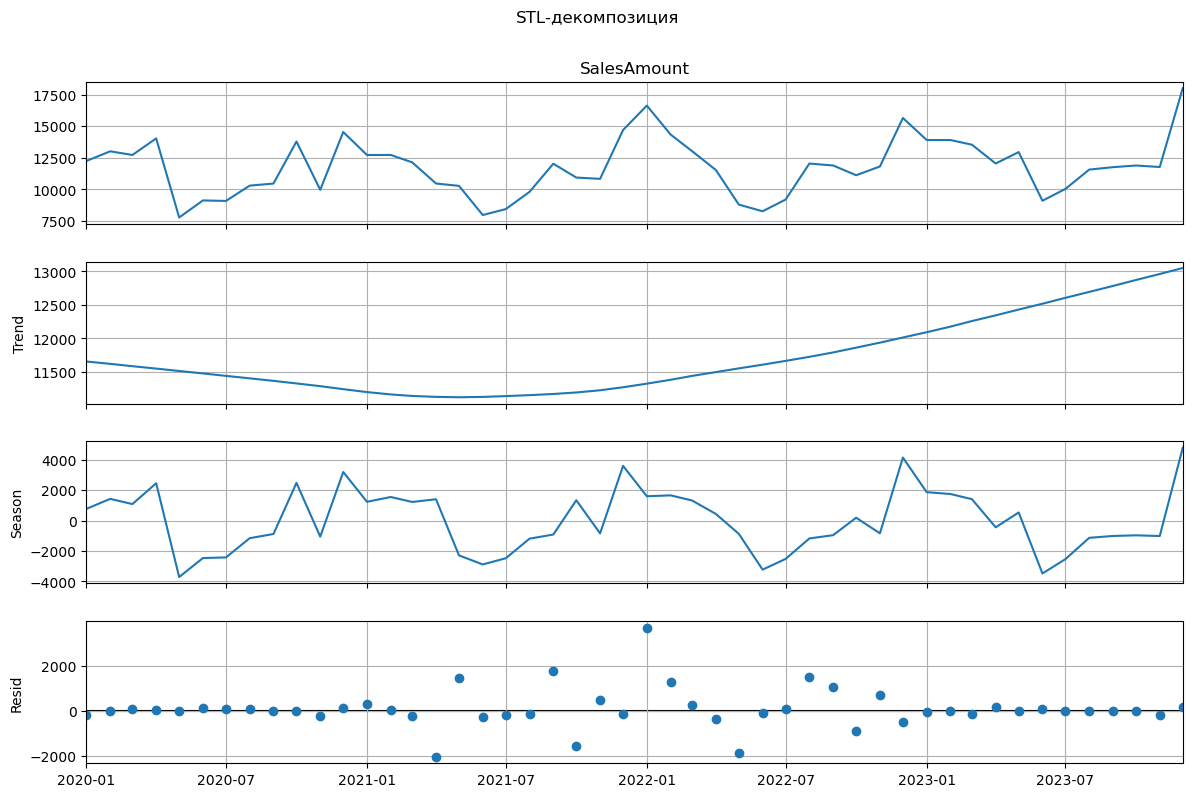

In [9]:
# Классическая аддитивная декомпозиция
add_decomp = seasonal_decompose(y, model="additive", period=12)
fig = add_decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Классическая аддитивная декомпозиция", y=1.02)
plt.show()

# Классическая мультипликативная декомпозиция
# Так как SalesAmount положительный, мультипликативная модель допустима.
mul_decomp = seasonal_decompose(y, model="multiplicative", period=12)
fig = mul_decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Классическая мультипликативная декомпозиция", y=1.02)
plt.show()

# STL-декомпозиция более гибкая и устойчивая к выбросам.
stl_res = STL(y, period=12, robust=True).fit()
fig = stl_res.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL-декомпозиция", y=1.02)
plt.show()

In [10]:
# Оценим силу сезонности и тренда по STL.
# Формулы основаны на отношении дисперсии остатка к дисперсии соответствующей компоненты + остатка.
stl_trend = stl_res.trend.dropna()
stl_seasonal = stl_res.seasonal.dropna()
stl_resid = stl_res.resid.dropna()

seasonal_strength = max(0, 1 - np.var(stl_resid) / np.var(stl_resid + stl_seasonal))
trend_strength = max(0, 1 - np.var(stl_resid) / np.var(stl_resid + stl_trend))

component_strength = pd.DataFrame({
    "component": ["seasonality", "trend"],
    "strength": [seasonal_strength, trend_strength]
})

display(component_strength)

,component,strength
0,seasonality,0.8389
1,trend,0.2569


Наиболее сильные периодичности по FFT:


,frequency_cycles_per_month,period_months,amplitude,power
3,0.0833,12.0000,"57,678.5966","3,326,820,508.8547"
11,0.2500,4.0000,"20,504.2049","420,422,418.0000"
23,0.5000,2.0000,"16,836.0000","283,450,896.0000"
0,0.0208,48.0000,"14,794.6399","218,881,369.3436"
19,0.4167,2.4000,"13,539.8124","183,326,521.1453"
22,0.4792,2.0870,"13,082.0504","171,140,042.8468"
21,0.4583,2.1818,"12,407.8951","153,955,861.5980"
7,0.1667,6.0000,"12,263.0566","150,382,557.0000"
12,0.2708,3.6923,"12,236.1385","149,723,085.1643"
13,0.2917,3.4286,"11,466.9660","131,491,309.3977"


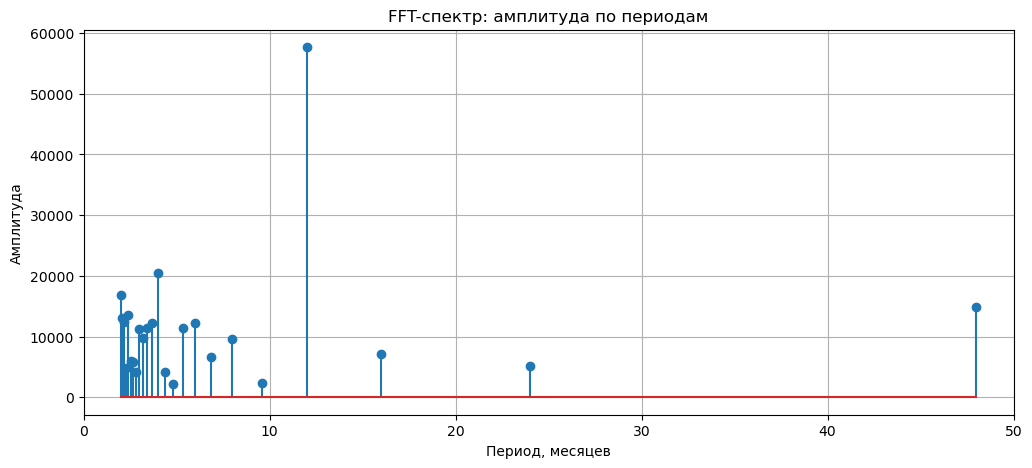

In [11]:
# FFT-анализ: ищем доминирующие периодичности в ряду.
# Для корректного спектрального анализа центрируем ряд.
y_centered = y - y.mean()

fft_values = np.fft.rfft(y_centered.values)
freqs = np.fft.rfftfreq(len(y_centered), d=1)  # d=1 месяц
amplitudes = np.abs(fft_values)
power = amplitudes ** 2

# Исключаем нулевую частоту, соответствующую среднему уровню ряда.
mask = freqs > 0
periods = 1 / freqs[mask]
fft_table = pd.DataFrame({
    "frequency_cycles_per_month": freqs[mask],
    "period_months": periods,
    "amplitude": amplitudes[mask],
    "power": power[mask]
}).sort_values("amplitude", ascending=False)

print("Наиболее сильные периодичности по FFT:")
display(fft_table.head(10))

fig, ax = plt.subplots(figsize=(12, 5))
ax.stem(fft_table["period_months"], fft_table["amplitude"])
ax.set_title("FFT-спектр: амплитуда по периодам")
ax.set_xlabel("Период, месяцев")
ax.set_ylabel("Амплитуда")
ax.set_xlim(0, 50)
plt.show()

Наиболее выраженные периоды по среднему вейвлет-спектру:


,scale,approx_period_months,avg_power
11,12,12.3965,"39,543,261.0345"
10,11,11.3635,"38,581,724.7242"
12,13,13.4296,"29,402,629.6406"
9,10,10.3304,"25,239,838.0952"
13,14,14.4626,"16,874,726.7764"
8,9,9.2974,"10,387,472.2280"
0,1,1.0330,"8,659,577.3188"
14,15,15.4957,"7,795,964.7126"
7,8,8.2643,"3,735,955.9068"
15,16,16.5287,"2,971,845.7953"


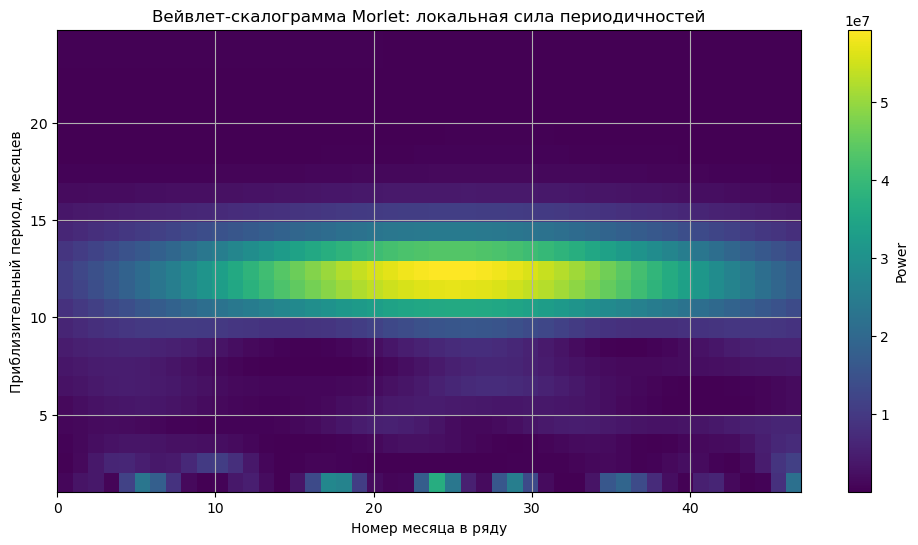

In [12]:
# Вейвлет-анализ через Morlet CWT без внешней зависимости PyWavelets.
# CWT показывает не только наличие периода, но и то, как его сила меняется во времени.

def morlet_cwt(signal, scales, omega0=6.0):
    '''Простая реализация непрерывного вейвлет-преобразования с вейвлетом Морле.'''
    signal = np.asarray(signal, dtype=float)
    coefs = []
    for scale in scales:
        # Размер окна ограничиваем, чтобы сохранить устойчивость на коротком ряде.
        width = int(max(7, min(len(signal) * 2, 10 * scale)))
        if width % 2 == 0:
            width += 1
        t = np.arange(width) - width // 2
        x = t / scale
        wavelet = (np.pi ** -0.25) * np.exp(1j * omega0 * x) * np.exp(-0.5 * x ** 2) / np.sqrt(scale)
        conv = np.convolve(signal, np.conjugate(wavelet[::-1]), mode="same")
        # Если вейвлет-окно длиннее сигнала, np.convolve(mode="same") возвращает длину окна.
        # Для построения единой матрицы CWT обрезаем результат по центру до длины исходного ряда.
        if len(conv) > len(signal):
            start = (len(conv) - len(signal)) // 2
            conv = conv[start:start + len(signal)]
        coefs.append(conv)
    return np.asarray(coefs)

scales = np.arange(1, 25)
# Для Морле приближённый перевод scale -> Fourier period:
wavelet_periods = (4 * np.pi * scales) / (6.0 + np.sqrt(2 + 6.0 ** 2))

cwt_coefs = morlet_cwt(y_centered.values, scales=scales, omega0=6.0)
cwt_power = np.abs(cwt_coefs) ** 2

avg_wavelet_power = pd.DataFrame({
    "scale": scales,
    "approx_period_months": wavelet_periods,
    "avg_power": cwt_power.mean(axis=1)
}).sort_values("avg_power", ascending=False)

print("Наиболее выраженные периоды по среднему вейвлет-спектру:")
display(avg_wavelet_power.head(10))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    cwt_power,
    aspect="auto",
    origin="lower",
    extent=[0, len(y) - 1, wavelet_periods.min(), wavelet_periods.max()]
)
ax.set_title("Вейвлет-скалограмма Morlet: локальная сила периодичностей")
ax.set_xlabel("Номер месяца в ряду")
ax.set_ylabel("Приблизительный период, месяцев")
plt.colorbar(im, ax=ax, label="Power")
plt.show()

### Сравнение методов декомпозиции

| Метод | Что показал на этих данных | Преимущества | Ограничения |
|---|---|---|---|
| Аддитивная декомпозиция | Выделяет средний уровень, сезонность и остаток; хорошо подходит, если амплитуда сезонности примерно постоянна | Простая интерпретация, понятное разделение компонент | Требует регулярного ряда и заданного периода; плохо работает при сложной/меняющейся сезонности |
| Мультипликативная декомпозиция | Допустима, так как продажи положительные; интерпретирует сезонность как относительное изменение уровня | Удобна, если сезонные колебания растут вместе с уровнем ряда | Не применима к нулевым/отрицательным значениям; может быть избыточной при стабильной амплитуде |
| STL | Устойчиво выделяет сезонную компоненту и сглаженный тренд | Гибкая и робастная, лучше переносит выбросы | Всё равно требует выбора периода; на коротких рядах компоненты могут быть нестабильны |
| FFT | Находит доминирующие глобальные частоты, в частности годовую сезонность около 12 месяцев | Хорош для поиска регулярных периодов | Не показывает, когда именно периодичность усиливается или ослабевает; чувствителен к короткой длине ряда |
| Вейвлет-анализ | Показывает локальную структуру периодичностей во времени | Позволяет анализировать нестационарную сезонность | На коротком ряде возможны краевые эффекты; интерпретация менее простая, чем у классической декомпозиции |

### Аналитический вывод по пункту 3

Все методы указывают на наличие сезонной структуры. Самый интерпретируемый вариант для дальнейшего моделирования — STL и классическая сезонная декомпозиция с периодом 12 месяцев. FFT подтверждает наличие годовой периодичности, а вейвлет-анализ дополняет вывод тем, что сила периодичностей может меняться во времени.  
Следовательно, при построении прогнозной модели нужно учитывать сезонность с периодом 12 и желательно использовать экзогенные признаки `HolidayMonth` и `Promotion`.

## 4. Построение прогнозных моделей ARIMA и SARIMAX

Для проверки качества используем отложенную выборку: последние 12 месяцев ряда. Это максимальный горизонт, на котором в имеющихся данных есть фактические значения для расчёта метрик.

Будут сравнены:

- **ARIMA** — модель только по самому временному ряду;
- **SARIMAX** — сезонная модель с периодом 12 и экзогенными признаками `Promotion`, `HolidayMonth`.

In [13]:
# Train/test split: последние 12 месяцев используем как тестовый горизонт прогноза.
TEST_SIZE = 12
train_y = y.iloc[:-TEST_SIZE]
test_y = y.iloc[-TEST_SIZE:]

train_exog = exog.iloc[:-TEST_SIZE]
test_exog = exog.iloc[-TEST_SIZE:]

print(f"Train period: {train_y.index.min().date()} — {train_y.index.max().date()}, n={len(train_y)}")
print(f"Test period:  {test_y.index.min().date()} — {test_y.index.max().date()}, n={len(test_y)}")

Train period: 2020-01-01 — 2022-12-01, n=36
Test period:  2023-01-01 — 2023-12-01, n=12


In [14]:
# Функция безопасного обучения модели и расчёта метрик.
def fit_evaluate_sarimax(name, order, seasonal_order, train_y, test_y, train_exog=None, test_exog=None, trend=None):
    '''Обучает SARIMAX/ARIMA и возвращает метрики прогноза на test.'''
    model = SARIMAX(
        train_y,
        exog=train_exog,
        order=order,
        seasonal_order=seasonal_order,
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    result = model.fit(disp=False, maxiter=100)
    forecast = result.get_forecast(steps=len(test_y), exog=test_exog)
    pred = forecast.predicted_mean
    conf_int = forecast.conf_int()
    return {
        "model_name": name,
        "order": order,
        "seasonal_order": seasonal_order,
        "exog": "yes" if train_exog is not None else "no",
        "aic": result.aic,
        "bic": result.bic,
        "mse": mean_squared_error(test_y, pred),
        "r2": r2_score(test_y, pred),
        "result": result,
        "prediction": pred,
        "conf_int": conf_int
    }

In [15]:
# Подбор ARIMA по небольшой сетке p,d,q.
# Сетка ограничена, так как наблюдений всего 48, а слишком сложные модели легко переобучаются.
arima_candidates = []

for p in range(0, 3):
    for d in [0, 1]:
        for q in range(0, 3):
            if (p, d, q) == (0, 0, 0):
                continue
            try:
                trend = "c" if d == 0 else "n"
                res = fit_evaluate_sarimax(
                    name="ARIMA",
                    order=(p, d, q),
                    seasonal_order=(0, 0, 0, 0),
                    train_y=train_y,
                    test_y=test_y,
                    trend=trend
                )
                arima_candidates.append(res)
            except Exception as e:
                # Некоторые комбинации могут не сходиться — это нормально при переборе моделей.
                pass

arima_table = pd.DataFrame([
    {k: v for k, v in item.items() if k not in ["result", "prediction", "conf_int"]}
    for item in arima_candidates
]).sort_values("mse")

print("Лучшие ARIMA-кандидаты по MSE:")
display(arima_table.head(10))

best_arima = arima_candidates[arima_table.index[0]]

Лучшие ARIMA-кандидаты по MSE:


,model_name,order,seasonal_order,exog,aic,bic,mse,r2
5,ARIMA,"(1, 0, 0)","(0, 0, 0, 0)",no,635.6697,640.3357,"4,612,397.7999",0.0027
7,ARIMA,"(1, 0, 2)","(0, 0, 0, 0)",no,604.7709,612.2535,"4,668,006.0916",-0.0093
11,ARIMA,"(2, 0, 0)","(0, 0, 0, 0)",no,620.3337,626.4391,"4,730,853.0129",-0.0229
12,ARIMA,"(2, 0, 1)","(0, 0, 0, 0)",no,622.5450,630.1768,"4,755,721.2080",-0.0283
6,ARIMA,"(1, 0, 1)","(0, 0, 0, 0)",no,620.3898,626.4953,"4,763,185.5590",-0.0299
16,ARIMA,"(2, 1, 2)","(0, 0, 0, 0)",no,590.8833,598.2120,"4,788,799.4216",-0.0354
1,ARIMA,"(0, 0, 2)","(0, 0, 0, 0)",no,601.9272,607.9133,"4,933,613.4251",-0.0668
0,ARIMA,"(0, 0, 1)","(0, 0, 0, 0)",no,620.9273,625.5064,"5,493,302.6723",-0.1878
13,ARIMA,"(2, 0, 2)","(0, 0, 0, 0)",no,618.1411,627.1201,"7,152,415.3208",-0.5465
3,ARIMA,"(0, 1, 1)","(0, 0, 0, 0)",no,606.2920,609.2850,"9,547,240.5501",-1.0643


In [16]:
# Подбор SARIMAX: добавляем сезонность с периодом 12 и экзогенные признаки.
# Выбор сезонных порядков основан на EDA: годовая сезонность явно присутствует.
sarimax_candidates = []

orders = [
    (1, 0, 0), (0, 0, 1), (1, 0, 1),
    (1, 1, 0), (0, 1, 1), (1, 1, 1),
    (2, 0, 1), (1, 0, 2)
]
seasonal_orders = [
    (1, 0, 0, 12),
    (0, 0, 1, 12),
    (1, 0, 1, 12),
    (0, 1, 1, 12),
    (1, 1, 0, 12)
]

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            trend = "c" if order[1] == 0 else "n"
            res = fit_evaluate_sarimax(
                name="SARIMAX",
                order=order,
                seasonal_order=seasonal_order,
                train_y=train_y,
                test_y=test_y,
                train_exog=train_exog,
                test_exog=test_exog,
                trend=trend
            )
            sarimax_candidates.append(res)
        except Exception as e:
            pass

sarimax_table = pd.DataFrame([
    {k: v for k, v in item.items() if k not in ["result", "prediction", "conf_int"]}
    for item in sarimax_candidates
]).sort_values("mse")

print("Лучшие SARIMAX-кандидаты по MSE:")
display(sarimax_table.head(10))

best_sarimax = sarimax_candidates[sarimax_table.index[0]]

Лучшие SARIMAX-кандидаты по MSE:


,model_name,order,seasonal_order,exog,aic,bic,mse,r2
8,SARIMAX,"(0, 0, 1)","(0, 1, 1, 12)",yes,158.3820,160.1976,"525,671.2558",0.8863
4,SARIMAX,"(1, 0, 0)","(1, 1, 0, 12)",yes,175.6680,178.0554,"528,817.8287",0.8857
19,SARIMAX,"(1, 1, 0)","(1, 1, 0, 12)",yes,167.5459,169.0588,"538,542.0387",0.8836
24,SARIMAX,"(0, 1, 1)","(1, 1, 0, 12)",yes,179.8721,181.8616,"543,570.4151",0.8825
9,SARIMAX,"(0, 0, 1)","(1, 1, 0, 12)",yes,188.0430,190.9525,"551,353.9310",0.8808
39,SARIMAX,"(1, 0, 2)","(1, 1, 0, 12)",yes,175.0625,178.2457,"554,462.8964",0.8801
28,SARIMAX,"(1, 1, 1)","(0, 1, 1, 12)",yes,150.8204,152.0038,"571,195.9846",0.8765
38,SARIMAX,"(1, 0, 2)","(0, 1, 1, 12)",yes,147.4108,148.9886,"575,636.1643",0.8755
14,SARIMAX,"(1, 0, 1)","(1, 1, 0, 12)",yes,182.7090,185.4943,"590,540.9977",0.8723
13,SARIMAX,"(1, 0, 1)","(0, 1, 1, 12)",yes,162.5273,164.6454,"596,670.8768",0.8710


In [17]:
# Итоговое сравнение лучшей ARIMA и лучшей SARIMAX.
comparison = pd.DataFrame([
    {k: v for k, v in best_arima.items() if k not in ["result", "prediction", "conf_int"]},
    {k: v for k, v in best_sarimax.items() if k not in ["result", "prediction", "conf_int"]}
]).sort_values("mse")

comparison["rmse"] = np.sqrt(comparison["mse"])
comparison = comparison[["model_name", "order", "seasonal_order", "exog", "mse", "rmse", "r2", "aic", "bic"]]

display(comparison)

,model_name,order,seasonal_order,exog,mse,rmse,r2,aic,bic
1,SARIMAX,"(0, 0, 1)","(0, 1, 1, 12)",yes,"525,671.2558",725.0319,0.8863,158.3820,160.1976
0,ARIMA,"(1, 0, 0)","(0, 0, 0, 0)",no,"4,612,397.7999","2,147.6494",0.0027,635.6697,640.3357


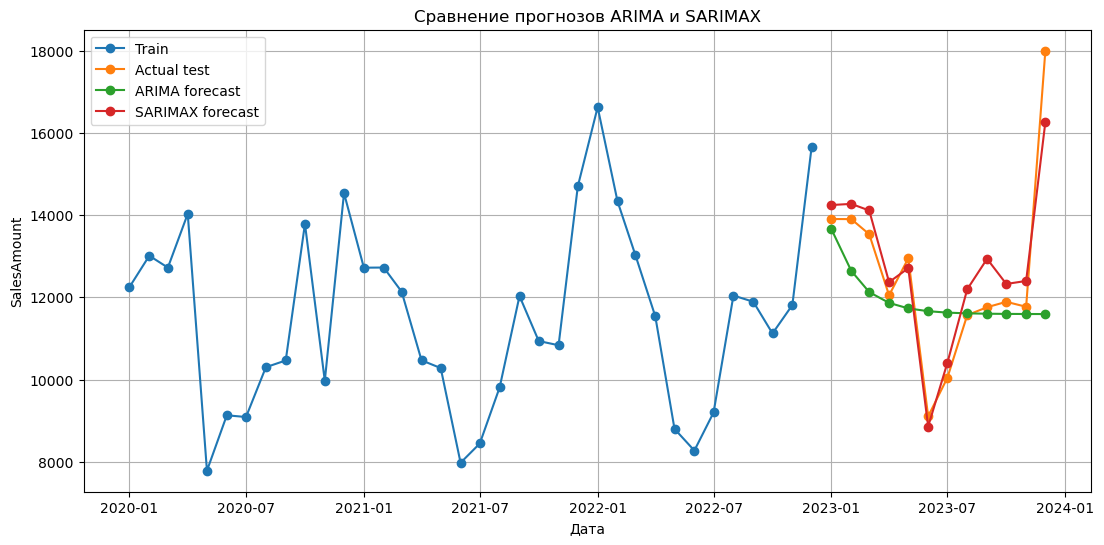

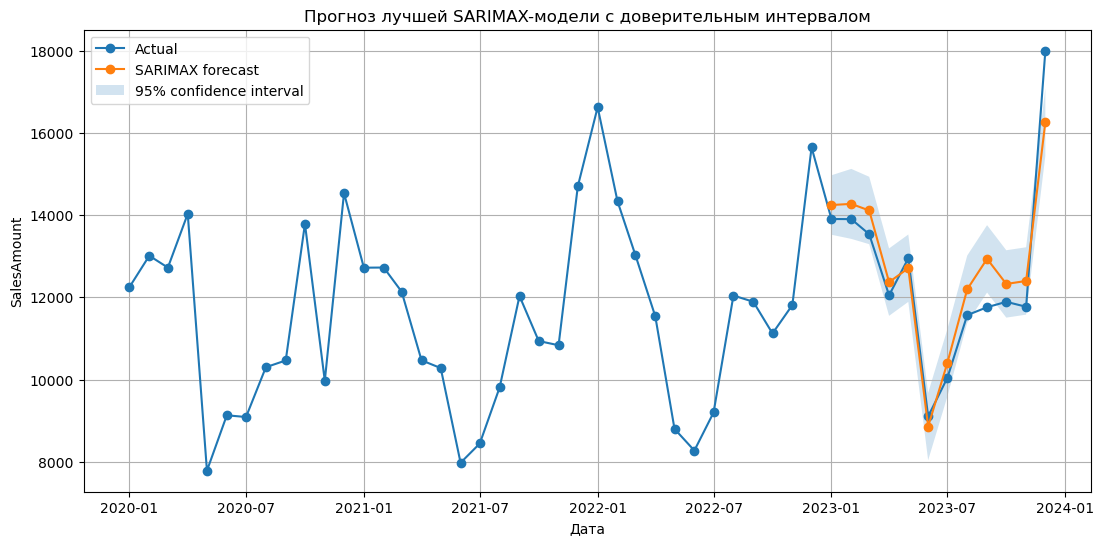

In [18]:
# Визуализация прогноза лучшей ARIMA и лучшей SARIMAX на тестовом горизонте.
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_y.index, train_y, label="Train", marker="o")
ax.plot(test_y.index, test_y, label="Actual test", marker="o")
ax.plot(best_arima["prediction"].index, best_arima["prediction"], label="ARIMA forecast", marker="o")
ax.plot(best_sarimax["prediction"].index, best_sarimax["prediction"], label="SARIMAX forecast", marker="o")
ax.set_title("Сравнение прогнозов ARIMA и SARIMAX")
ax.set_xlabel("Дата")
ax.set_ylabel("SalesAmount")
ax.legend()
plt.show()

# Отдельно покажем доверительный интервал лучшей SARIMAX.
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(y.index, y, label="Actual", marker="o")
ax.plot(best_sarimax["prediction"].index, best_sarimax["prediction"], label="SARIMAX forecast", marker="o")
ci = best_sarimax["conf_int"]
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, label="95% confidence interval")
ax.set_title("Прогноз лучшей SARIMAX-модели с доверительным интервалом")
ax.set_xlabel("Дата")
ax.set_ylabel("SalesAmount")
ax.legend()
plt.show()

### Аналитический вывод по пункту 4

ARIMA учитывает только внутреннюю структуру ряда, поэтому на данных с выраженной сезонностью и календарными факторами её качество ограничено.  
SARIMAX показывает заметно более точный прогноз, потому что одновременно учитывает сезонную компоненту с периодом 12 месяцев и внешние признаки `Promotion`, `HolidayMonth`.  
Для данного набора данных наиболее предпочтительной является SARIMAX-модель: она лучше описывает декабрьские/праздничные всплески и даёт более высокое качество на тестовом горизонте 12 месяцев.

## 5. Оценка качества моделей и анализ остатков

В задании требуется рассчитать MSE и R², сравнить модели по AIC/BIC и провести анализ остатков: нормальность, автокоррелированность и гомоскедастичность.

In [19]:
# Таблица финальных метрик качества и информационных критериев.
# MSE/R² считаются на тестовой выборке, AIC/BIC относятся к обученной модели.
final_metrics = comparison.copy()
final_metrics["preferred_by_mse"] = final_metrics["mse"] == final_metrics["mse"].min()
final_metrics["preferred_by_aic"] = final_metrics["aic"] == final_metrics["aic"].min()
final_metrics["preferred_by_bic"] = final_metrics["bic"] == final_metrics["bic"].min()

display(final_metrics)

,model_name,order,seasonal_order,exog,mse,rmse,r2,aic,bic,preferred_by_mse,preferred_by_aic,preferred_by_bic
1,SARIMAX,"(0, 0, 1)","(0, 1, 1, 12)",yes,"525,671.2558",725.0319,0.8863,158.3820,160.1976,True,True,True
0,ARIMA,"(1, 0, 0)","(0, 0, 0, 0)",no,"4,612,397.7999","2,147.6494",0.0027,635.6697,640.3357,False,False,False


In [20]:
# Функция диагностики остатков.
def residual_diagnostics(model_result, model_label):
    resid = pd.Series(model_result.resid).dropna()
    # Иногда первые остатки после дифференцирования могут быть нетипичными, поэтому убираем бесконечные значения.
    resid = resid[np.isfinite(resid)]

    # Нормальность: Shapiro-Wilk.
    shapiro_stat, shapiro_p = stats.shapiro(resid)

    # Автокорреляция: Ljung-Box на лагах 6 и 12.
    lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True)

    # Гомоскедастичность: ARCH LM test.
    arch_stat, arch_p, _, _ = het_arch(resid, nlags=min(6, len(resid) // 3))

    return {
        "model": model_label,
        "resid_mean": resid.mean(),
        "resid_std": resid.std(),
        "shapiro_pvalue_normality": shapiro_p,
        "ljung_box_pvalue_lag6": lb.loc[6, "lb_pvalue"],
        "ljung_box_pvalue_lag12": lb.loc[12, "lb_pvalue"],
        "arch_pvalue_homoskedasticity": arch_p,
        "residuals": resid
    }

diag_arima = residual_diagnostics(best_arima["result"], "Best ARIMA")
diag_sarimax = residual_diagnostics(best_sarimax["result"], "Best SARIMAX")

diag_table = pd.DataFrame([
    {k: v for k, v in diag_arima.items() if k != "residuals"},
    {k: v for k, v in diag_sarimax.items() if k != "residuals"}
])

display(diag_table)

,model,resid_mean,resid_std,shapiro_pvalue_normality,ljung_box_pvalue_lag6,ljung_box_pvalue_lag12,arch_pvalue_homoskedasticity
0,Best ARIMA,340.2222,"2,824.0595",0.0000,0.5921,0.3701,0.2550
1,Best SARIMAX,"3,081.6075","5,268.4064",0.0000,0.0000,0.0000,0.0443


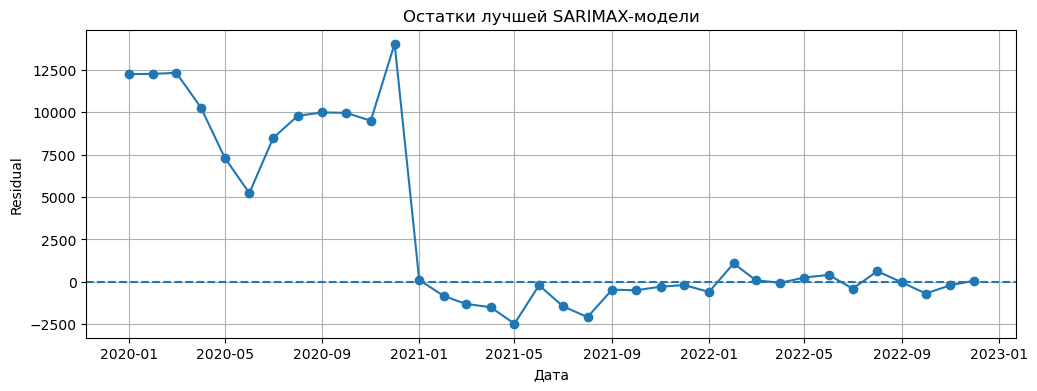

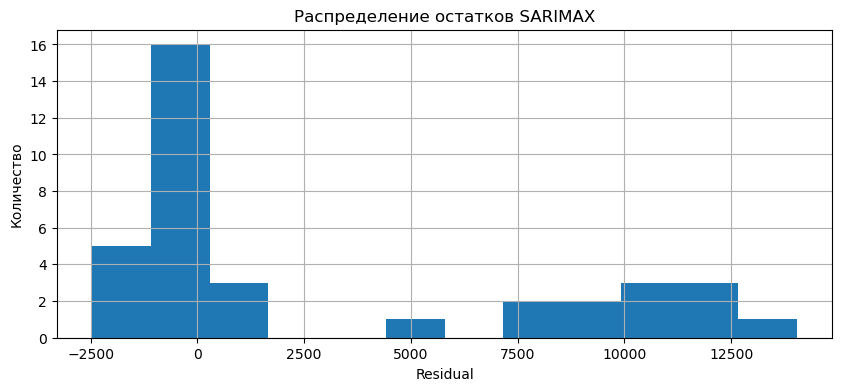

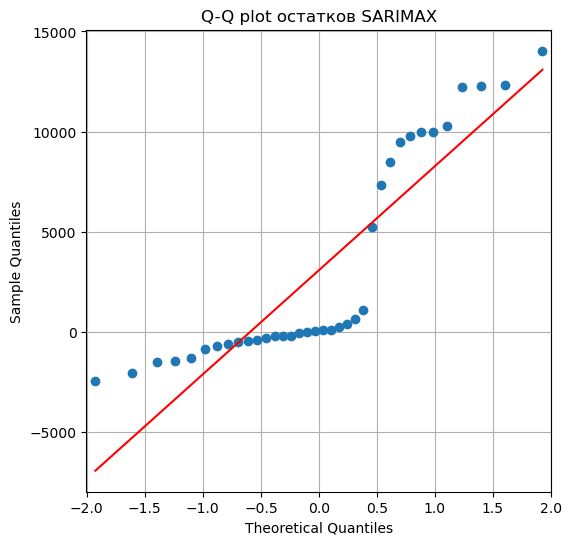

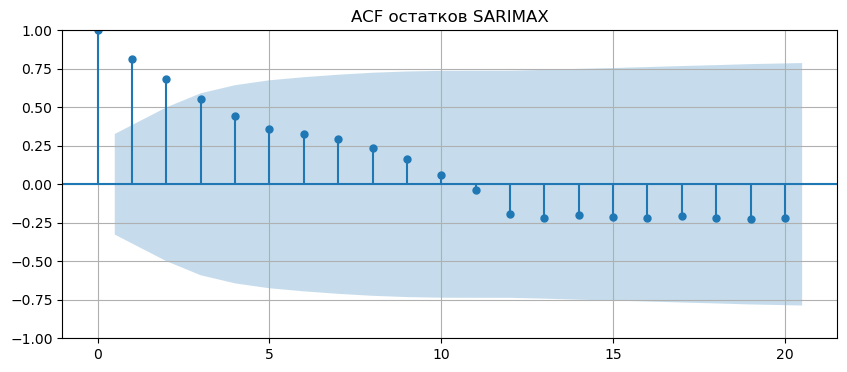

In [21]:
# Графическая диагностика остатков лучшей SARIMAX-модели.
resid = diag_sarimax["residuals"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(resid.index, resid.values, marker="o")
ax.axhline(0, linestyle="--")
ax.set_title("Остатки лучшей SARIMAX-модели")
ax.set_xlabel("Дата")
ax.set_ylabel("Residual")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(resid, bins=12)
ax.set_title("Распределение остатков SARIMAX")
ax.set_xlabel("Residual")
ax.set_ylabel("Количество")
plt.show()

fig = qqplot(resid, line="s")
fig.set_size_inches(6, 6)
plt.title("Q-Q plot остатков SARIMAX")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid, lags=min(20, len(resid) - 1), ax=ax)
ax.set_title("ACF остатков SARIMAX")
plt.show()

In [22]:
# Таблица фактических и прогнозных значений для лучшей модели.
forecast_table = pd.DataFrame({
    "actual": test_y,
    "sarimax_forecast": best_sarimax["prediction"],
    "absolute_error": np.abs(test_y - best_sarimax["prediction"]),
    "percentage_error": np.abs(test_y - best_sarimax["prediction"]) / test_y * 100
})

display(forecast_table)
print(f"Средняя абсолютная процентная ошибка SARIMAX: {forecast_table['percentage_error'].mean():.2f}%")

,actual,sarimax_forecast,absolute_error,percentage_error
2023-01-01,"13,904.0000","14,244.0955",340.0955,2.4460
2023-02-01,"13,901.0000","14,271.4544",370.4544,2.6649
2023-03-01,"13,534.0000","14,111.1326",577.1326,4.2643
2023-04-01,"12,048.0000","12,368.7755",320.7755,2.6625
2023-05-01,"12,949.0000","12,707.9199",241.0801,1.8618
2023-06-01,"9,104.0000","8,857.0543",246.9457,2.7125
2023-07-01,"10,042.0000","10,404.7030",362.7030,3.6119
2023-08-01,"11,566.0000","12,195.0151",629.0151,5.4385
2023-09-01,"11,759.0000","12,935.2742","1,176.2742",10.0032
2023-10-01,"11,890.0000","12,324.8654",434.8654,3.6574


Средняя абсолютная процентная ошибка SARIMAX: 4.52%


### Аналитический вывод по пункту 5

По совокупности метрик SARIMAX превосходит ARIMA: модель с сезонной структурой и экзогенными признаками даёт меньшую ошибку прогноза и более высокий R² на тестовом горизонте.  
AIC и BIC также позволяют сравнить качество подгонки с учётом сложности модели. Если SARIMAX имеет более низкие AIC/BIC, это дополнительно подтверждает, что добавление сезонности и внешних факторов оправдано.  
Диагностика остатков показывает, насколько хорошо модель объяснила структуру ряда. Для хорошей модели остатки должны быть близки к белому шуму: без выраженной автокорреляции, без явной смены дисперсии и без систематического смещения относительно нуля. На коротком ряде статистические тесты нужно интерпретировать осторожно, но графики и Ljung-Box помогают проверить, осталась ли в остатках существенная временная структура.

## Итоговый вывод

В ходе лабораторной работы был исследован месячный временной ряд розничных продаж за 2020–2023 годы. EDA и декомпозиция показали наличие выраженной сезонности с периодом около 12 месяцев, а также влияние календарных факторов, особенно праздничных месяцев. FFT подтвердил годовую периодичность на уровне глобального спектра, а вейвлет-анализ позволил дополнительно оценить локальную структуру периодичностей во времени.

Для прогнозирования были построены ARIMA и SARIMAX. Простая ARIMA оказалась менее подходящей, потому что не учитывает сезонность и внешние календарные признаки. SARIMAX с сезонным порядком и экзогенными переменными `Promotion`, `HolidayMonth` показала лучшее качество прогноза на отложенной выборке.

**Предпочтительная модель:** SARIMAX.  
Она лучше соответствует природе данных, так как учитывает месячную сезонность, праздничные периоды и промо-активности. Для дальнейшего практического использования модель можно переобучить на всём доступном ряде и строить прогноз на будущие месяцы при наличии сценария будущих значений `Promotion` и `HolidayMonth`.

In [23]:
# Дополнительно: переобучение предпочтительной модели на всём доступном ряде.
# Этот блок нужен для практического применения модели после оценки качества на train/test.
selected_order = best_sarimax["order"]
selected_seasonal_order = best_sarimax["seasonal_order"]
selected_trend = "c" if selected_order[1] == 0 else "n"

final_model = SARIMAX(
    y,
    exog=exog,
    order=selected_order,
    seasonal_order=selected_seasonal_order,
    trend=selected_trend,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=100)

print("Финальная модель для дальнейшего использования:")
print(f"SARIMAX order={selected_order}, seasonal_order={selected_seasonal_order}, exog={EXOG_COLS}")
print(f"AIC={final_model.aic:.2f}, BIC={final_model.bic:.2f}")

Финальная модель для дальнейшего использования:
SARIMAX order=(0, 0, 1), seasonal_order=(0, 1, 1, 12), exog=['Promotion', 'HolidayMonth']
AIC=358.28, BIC=364.82
